# Modelo Híbrido
El objetivo de este notebook es combinar los modelos que hicimos hasta ahroa en un solo modelo y evaluar la performance.

Este modelo:
1. Clasifica cada muestra en normal (0) u outlier (1)
2. En caso de ser normal, estima el precio del alquiler usando el modelo optimizado para muestras normales
3. En caso de ser outlier, estima el precio usando el modelo optimizado para outliers

In [27]:
import pandas as pd
from sklearn import set_config

import os, sys

from src.models.mlp import get_best_mlp

sys.path.append(os.path.abspath(".."))

%load_ext autoreload
%autoreload 2

from src.config import TREE_BASED_CONFIG_NORMAL, TREE_BASED_CONFIG_OUTLIERS
from src.model_evaluation import evaluate_models_cv
from src.models.base_models import get_base_xgboost
from src.models.hybrid import get_hybrid_model
from src.models.xgboost_models import get_xgboost_full
from src.pipeline import build_base_pipeline, build_feature_pipeline, build_target_pipeline
from src.plots import plot_cv_results
from src.constants import DEV_SET_CLEAN_PATH, TARGET

set_config(transform_output="pandas")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
# usamos dataset completo !!
df = pd.read_csv("../" + DEV_SET_CLEAN_PATH)
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [29]:
feature_pipeline = build_feature_pipeline(TREE_BASED_CONFIG_OUTLIERS)
target_pipeline = build_target_pipeline(TREE_BASED_CONFIG_OUTLIERS)

## Definimos modelos a comparar

### XGBoost base sin preprocesar

In [30]:
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()

base_preprocessor = build_base_pipeline(numeric_cols, categorical_cols)
base_xgboost = get_base_xgboost(base_preprocessor)

### XGBoost base preprocesado

In [31]:
base_xgboost_preprocessed = get_base_xgboost(feature_pipeline)

### Mejor XGBoost

In [32]:
best_xgboost = get_xgboost_full()

### Modelo Híbrido

In [33]:
hybrid_xgboost = get_hybrid_model()

### MLP

In [34]:
mlp = get_best_mlp()

# Comparación final con CV

In [35]:
models = {
    "Baseline (XGBoost)": base_xgboost,
    "XGBoost + Preprocessing": base_xgboost_preprocessed,
    "XGBoost Optimizado": best_xgboost,
    "XGBoost Híbrido": hybrid_xgboost,
    "Red Neuronal (MLP)": mlp,
}

In [36]:
results = evaluate_models_cv(
    models,
    X,
    y,
    feature_pipeline=None, # los modelos ya tienen pipeline,
    target_pipeline=None,
    n_splits=5,
    random_state=42
)


🔄 Ejecutando 5-Fold Cross-Validation...

Entrenando Baseline (XGBoost)...
  ✓ MAE:   95,505 ± 1,864
  ✓ RMSE:  436,177 ± 44,519
  ✓ R²:    0.5777 ± 0.0695
  ✓ MAPE:  7.04% ± 0.27%
  ✓ MedAE: 36,114 ± 460

Entrenando XGBoost + Preprocessing...
  ✓ MAE:   93,855 ± 1,378
  ✓ RMSE:  431,724 ± 41,055
  ✓ R²:    0.5859 ± 0.0670
  ✓ MAPE:  6.94% ± 0.09%
  ✓ MedAE: 35,370 ± 256

Entrenando XGBoost Optimizado...
  ✓ MAE:   54,109 ± 1,698
  ✓ RMSE:  397,520 ± 40,709
  ✓ R²:    0.6505 ± 0.0505
  ✓ MAPE:  3.77% ± 0.30%
  ✓ MedAE: 8,813 ± 34

Entrenando XGBoost Híbrido...
  ✓ MAE:   29,022 ± 2,586
  ✓ RMSE:  426,409 ± 60,836
  ✓ R²:    0.5954 ± 0.0934
  ✓ MAPE:  1.65% ± 0.34%
  ✓ MedAE: 978 ± 7

Entrenando Red Neuronal (MLP)...
  ✓ MAE:   120,313 ± 1,507
  ✓ RMSE:  671,491 ± 46,799
  ✓ R²:    0.0079 ± 0.0019
  ✓ MAPE:  7.44% ± 0.33%
  ✓ MedAE: 57,303 ± 2,230



In [37]:
results[["mae_mean", "rmse_mean", "mse_mean", "r2_mean", "mape_mean", "medae_mean"]]

,mae_mean,rmse_mean,mse_mean,r2_mean,mape_mean,medae_mean
XGBoost Híbrido,29021.759353,426408.841214,1.855255e+11,0.595416,1.650224,978.065685
XGBoost Optimizado,54109.326714,397520.475819,1.596797e+11,0.650471,3.766784,8812.587957
XGBoost + Preprocessing,93854.788143,431723.664416,1.880709e+11,0.585862,6.936313,35369.727438
Baseline (XGBoost),95505.119464,436176.965044,1.922323e+11,0.577741,7.039895,36113.840899
Red Neuronal (MLP),120313.468772,671491.365291,4.530908e+11,0.007900,7.444879,57302.921892


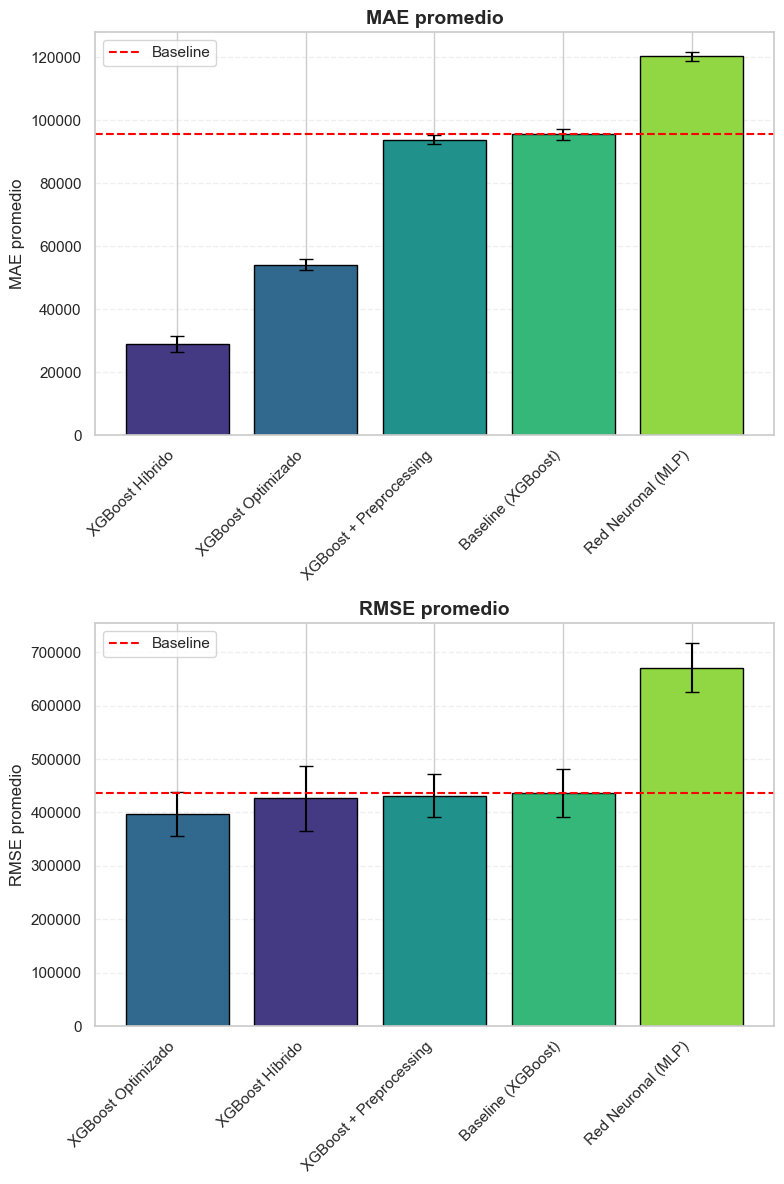

In [41]:
plot_cv_results(results, baseline_name="Baseline (XGBoost)", show_train=False, metrics=["mae", "rmse"], filename="comparacion-final")